In [1]:

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import pickle

In [2]:
# Importing the dataset

import pandas as pd
Development = pd.read_csv("../dataset/HDI.csv")
Development.head()

,HDI rank,Country,Human Development Index (HDI),Life expectancy at birth,Expected years of schooling,Mean years of schooling,Gross national income (GNI) per capita,GNI per capita rank minus HDI rank,Previous HDI rank
0,1.0,Iceland,0.972,82.691,18.850590,13.908926,69116.93736,12,3
1,2.0,Norway,0.970,83.308,18.792850,13.117962,112710.02110,0,1
2,2.0,Switzerland,0.970,83.954,16.667530,13.949121,81948.90177,5,2
3,4.0,Denmark,0.962,81.933,18.704010,13.027321,76007.85669,4,4
4,5.0,Germany,0.959,81.378,17.309219,14.296372,64053.22124,13,6


In [3]:
# Number of rows and columns
Development.shape

(193, 9)

In [4]:
# Dataset information
Development.info()

<class 'pandas.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 9 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   HDI rank                                193 non-null    float64
 1   Country                                 193 non-null    str    
 2   Human Development Index (HDI)           193 non-null    float64
 3   Life expectancy at birth                193 non-null    float64
 4   Expected years of schooling             193 non-null    float64
 5   Mean years of schooling                 193 non-null    float64
 6   Gross national income (GNI) per capita  193 non-null    float64
 7   GNI per capita rank minus HDI rank      193 non-null    int64  
 8   Previous HDI rank                       193 non-null    str    
dtypes: float64(6), int64(1), str(2)
memory usage: 13.7 KB


In [5]:
# Display all column names
Development.columns

Index(['HDI rank', 'Country', 'Human Development Index (HDI)',
       'Life expectancy at birth', 'Expected years of schooling',
       'Mean years of schooling', 'Gross national income (GNI) per capita',
       'GNI per capita rank minus HDI rank', 'Previous HDI rank'],
      dtype='str')

In [6]:
# Statistical summary
Development.describe()

,HDI rank,Human Development Index (HDI),Life expectancy at birth,Expected years of schooling,Mean years of schooling,Gross national income (GNI) per capita,GNI per capita rank minus HDI rank
count,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000
mean,96.797927,0.740798,73.111523,13.584760,9.173346,24620.680478,0.202073
std,55.927647,0.151608,7.166191,3.074275,3.186835,25961.982601,14.345281
min,1.000000,0.388000,54.462000,5.634770,1.412289,688.347277,-54.000000
25%,48.000000,0.622000,67.385000,11.504560,6.780046,5746.568969,-7.000000
50%,97.000000,0.762000,73.490000,13.335777,9.933020,15866.542070,1.000000
75%,145.000000,0.862000,78.341000,15.888260,11.641718,36792.988740,10.000000
max,193.000000,0.972000,85.706000,20.845501,14.296372,166811.674100,38.000000


In [7]:
# Missing values
Development.isnull().sum()

HDI rank                                  0
Country                                   0
Human Development Index (HDI)             0
Life expectancy at birth                  0
Expected years of schooling               0
Mean years of schooling                   0
Gross national income (GNI) per capita    0
GNI per capita rank minus HDI rank        0
Previous HDI rank                         0
dtype: int64

In [8]:
# Unique Country Values
Development["Country"].unique()

<StringArray>
[                 'Iceland',                   'Norway',
              'Switzerland',                  'Denmark',
                  'Germany',                   'Sweden',
                'Australia',   'Hong Kong, China (SAR)',
              'Netherlands',                  'Belgium',
 ...
                    'Yemen',             'Sierra Leone',
             'Burkina Faso',                  'Burundi',
                     'Mali',                    'Niger',
                     'Chad', 'Central African Republic',
                  'Somalia',              'South Sudan']
Length: 193, dtype: str

In [9]:
# Total number of countries
Development["Country"].nunique()

193

In [10]:

data1 = Development.head(20)
data1

,HDI rank,Country,Human Development Index (HDI),Life expectancy at birth,Expected years of schooling,Mean years of schooling,Gross national income (GNI) per capita,GNI per capita rank minus HDI rank,Previous HDI rank
0,1.0,Iceland,0.972,82.691,18.850590,13.908926,69116.93736,12,3
1,2.0,Norway,0.970,83.308,18.792850,13.117962,112710.02110,0,1
2,2.0,Switzerland,0.970,83.954,16.667530,13.949121,81948.90177,5,2
3,4.0,Denmark,0.962,81.933,18.704010,13.027321,76007.85669,4,4
4,5.0,Germany,0.959,81.378,17.309219,14.296372,64053.22124,13,6
5,5.0,Sweden,0.959,83.262,18.991470,12.740326,66102.08595,10,4
6,7.0,Australia,0.958,83.923,20.654779,12.870000,58276.87643,14,8
7,8.0,"Hong Kong, China (SAR)",0.955,85.511,16.895861,12.350000,69435.75706,4,9
8,8.0,Netherlands,0.955,82.158,18.584850,12.669947,68344.30826,6,7
9,10.0,Belgium,0.951,82.115,18.996031,12.689650,63582.47535,9,13


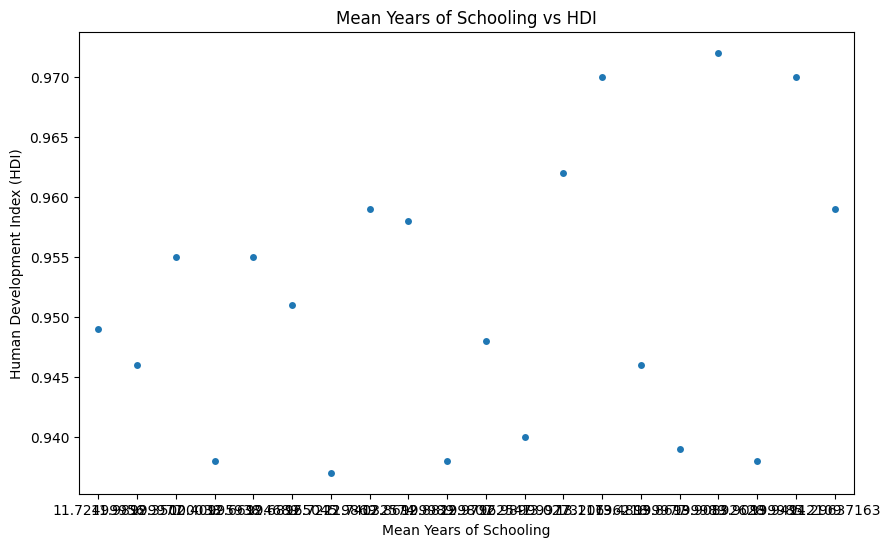

In [11]:
# Mean Years of Schooling vs HDI

plt.figure(figsize=(10,6))

sns.stripplot(
    x="Mean years of schooling",
    y="Human Development Index (HDI)",
    data=data1,
    jitter=True
)

plt.title("Mean Years of Schooling vs HDI")
plt.xlabel("Mean Years of Schooling")
plt.ylabel("Human Development Index (HDI)")

plt.show()

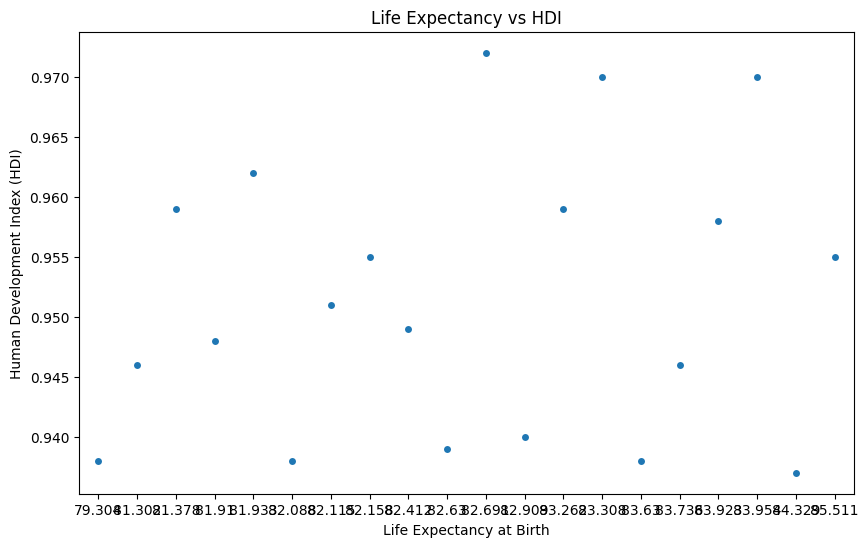

In [12]:
# Life Expectancy vs HDI

plt.figure(figsize=(10,6))

sns.stripplot(
    x="Life expectancy at birth",
    y="Human Development Index (HDI)",
    data=data1,
    jitter=True
)

plt.title("Life Expectancy vs HDI")
plt.xlabel("Life Expectancy at Birth")
plt.ylabel("Human Development Index (HDI)")

plt.show()

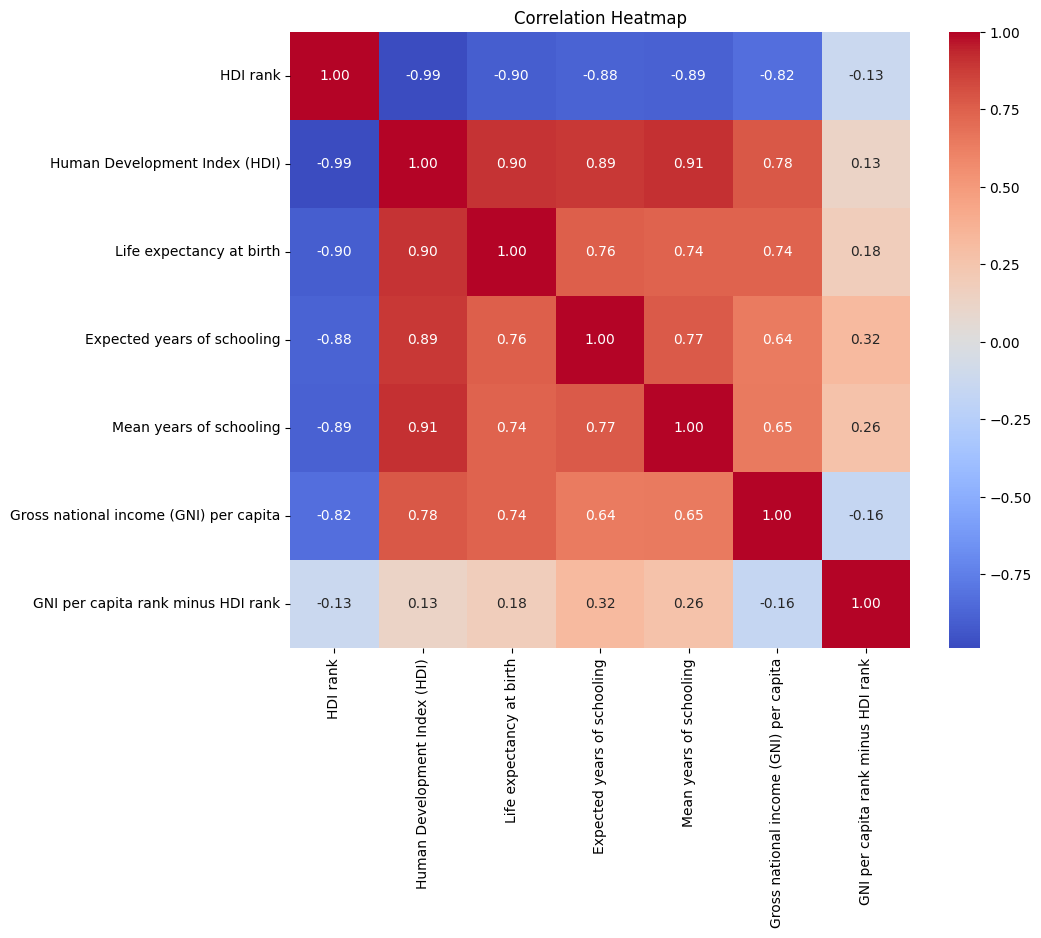

In [13]:
# Correlation Heatmap

plt.figure(figsize=(10,8))

numeric_data = Development.select_dtypes(include=["number"])

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [14]:
# Independent Variables (X)

X = Development.iloc[:, [3,4,5,6]]
X = pd.DataFrame(X)
X.head()

,Life expectancy at birth,Expected years of schooling,Mean years of schooling,Gross national income (GNI) per capita
0,82.691,18.850590,13.908926,69116.93736
1,83.308,18.792850,13.117962,112710.02110
2,83.954,16.667530,13.949121,81948.90177
3,81.933,18.704010,13.027321,76007.85669
4,81.378,17.309219,14.296372,64053.22124


In [15]:
# Dependent Variable (Y)

y = Development.iloc[:, 2]
y = pd.DataFrame(y)
y.head()

,Human Development Index (HDI)
0,0.972
1,0.970
2,0.970
3,0.962
4,0.959


In [16]:
X.isnull().sum()

Life expectancy at birth                  0
Expected years of schooling               0
Mean years of schooling                   0
Gross national income (GNI) per capita    0
dtype: int64

In [17]:
# Train and Test Split

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.10,
    random_state=42
)

In [18]:
# Shape of Training and Testing Data

print("x_train shape :", x_train.shape)
print("x_test shape  :", x_test.shape)
print("y_train shape :", y_train.shape)
print("y_test shape  :", y_test.shape)

x_train shape : (173, 4)
x_test shape  : (20, 4)
y_train shape : (173, 1)
y_test shape  : (20, 1)


In [19]:
# Importing and Creating the Linear Regression Model
reg = LinearRegression()

In [20]:
# Training the Model
reg.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 4)","[[0.01,0.01,0.02,0. ]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Life expectancy at birth','Expected years of schooling', 'Mean years of schooling','Gross national income (GNI) per capita']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-0.12]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [21]:
# Predicting HDI values for the Test Set

y_pred = reg.predict(x_test)
print(y_pred)

[[0.85907411]
 [0.64783136]
 [0.78063313]
 [0.62373436]
 [0.68971709]
 [0.61483599]
 [0.94473562]
 [0.93902104]
 [1.01183035]
 [0.96869835]
 [0.79851384]
 [0.70617794]
 [0.79335741]
 [0.79825379]
 [0.57635549]
 [0.9118006 ]
 [0.58991613]
 [0.80914138]
 [0.71628176]
 [0.8037791 ]]


In [22]:
# Predicting HDI values for the Test Set

y_pred = reg.predict(x_test)
print(y_pred)

[[0.85907411]
 [0.64783136]
 [0.78063313]
 [0.62373436]
 [0.68971709]
 [0.61483599]
 [0.94473562]
 [0.93902104]
 [1.01183035]
 [0.96869835]
 [0.79851384]
 [0.70617794]
 [0.79335741]
 [0.79825379]
 [0.57635549]
 [0.9118006 ]
 [0.58991613]
 [0.80914138]
 [0.71628176]
 [0.8037791 ]]


In [23]:

print(y_test.values)

[[0.87 ]
 [0.649]
 [0.798]
 [0.622]
 [0.722]
 [0.598]
 [0.939]
 [0.938]
 [0.938]
 [0.951]
 [0.794]
 [0.728]
 [0.819]
 [0.82 ]
 [0.588]
 [0.915]
 [0.617]
 [0.811]
 [0.731]
 [0.811]]


In [24]:
# R-Squared Score
r2 = r2_score(y_test, y_pred)
print("R2 Score :", r2)

R2 Score : 0.9635469574189839


In [25]:
print("Mean Absolute Error :", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error :", mean_squared_error(y_test, y_pred))

Mean Absolute Error : 0.01590251245196412
Mean Squared Error : 0.0005163845968094221


In [27]:
sample = pd.DataFrame({
    "Life expectancy at birth": [82.69],
    "Expected years of schooling": [18.85],
    "Mean years of schooling": [13.90],
    "Gross national income (GNI) per capita": [69116.94]
})

prediction = reg.predict(sample)
print("Predicted HDI:", prediction)

Predicted HDI: [[0.99694796]]


In [28]:
# Saving the trained model

import pickle
with open("../flask/HDI.pkl", "wb") as file:
    pickle.dump(reg, file)
    
print("Model saved successfully!")

Model saved successfully!
